# World Happiness Analisis

## About the data set
##### The World Happiness Report is a landmark survey of the state of global happiness. The reports review the state of happiness in the world today and show how the new science of happiness explains personal and national variations in happiness. This is a public dataset available on the Kaggle website as World Happiness Report under the CC0: Public Domain license.

##### World Happiness Report Dashboard Narrative

Welcome to our interactive dashboard on the World Happiness Report, which provides a multi-dimensional view of factors influencing happiness across countries. This dashboard combines four key visualizations to help us understand the drivers of happiness globally.

In [29]:
# beautiful style for jupyter notebook
from IPython.display import HTML

HTML("""
<style>
h1 {color:#2E86C1; font-weight:700;}
h2 {color:#117A65;}
h3 {color:#AF601A;}
body {font-family: 'Segoe UI';}
</style>
""")

In [30]:

!pip install -q kaggle

import os
import pandas as pd

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

!cp kaggle.json ~/.kaggle/ 2>/dev/null || copy kaggle.json %USERPROFILE%\.kaggle\
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null

!kaggle datasets download -d unsdsn/world-happiness -f 2016.csv --force

df = pd.read_csv("2016.csv")

print("OK")
print("Shape:", df.shape)
df.head()





[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
‘ЁбвҐ¬Ґ ­Ґ г¤ Ґвбп ­ ©вЁ гЄ § ­­л© Їгвм.
‘ЁбвҐ¬Ґ ­Ґ г¤ Ґвбп ­ ©вЁ гЄ § ­­л© Їгвм.


Dataset URL: https://www.kaggle.com/datasets/unsdsn/world-happiness


  0%|          | 0.00/16.7k [00:00<?, ?B/s]

License(s): CC0-1.0

100%|##########| 16.7k/16.7k [00:00<00:00, 1.01MB/s]


OK
Shape: (157, 13)


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


Data Cleaning - Change the data types

In [31]:
print("Current dtypes:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

df_inferred = df.convert_dtypes()

print("\nDtypes after convert_dtypes():")
print(df_inferred.dtypes)

changes = []
for col in df.columns:
    if df[col].dtype != df_inferred[col].dtype:
        changes.append((col, df[col].dtype, df_inferred[col].dtype))

if changes:
    print("\nColumns that would change dtype with convert_dtypes():")
    for col, old, new in changes:
        print(f"  {col}: {old} -> {new}")
else:
    print("\nNo dtype changes with convert_dtypes().")

numeric_like = []
for col in df.columns:
    if df[col].dtype == object:
        coerced = pd.to_numeric(df[col], errors='coerce')
        if df[col].notna().sum() > 0 and coerced.notna().sum() == df[col].notna().sum():
            numeric_like.append(col)

if numeric_like:
    print("\nObject columns that look numeric (convert to numeric):", numeric_like)


Current dtypes:
Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

Missing values per column:
Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity              

In [32]:
import numpy as np

def strip_whitespace_from_column(df, col):
    s = df[col]
    if pd.api.types.is_string_dtype(s) or pd.api.types.is_object_dtype(s):
        df[col] = s.apply(lambda v: v.strip() if isinstance(v, str) else v)
    return df

def empty_strings_to_nan(df, col):
    s = df[col]
    if pd.api.types.is_string_dtype(s) or pd.api.types.is_object_dtype(s):
        df[col] = s.replace('', np.nan)
        df[col] = df[col].replace(r'^\s+$', np.nan, regex=True)
    return df

cols_to_fix = ['Country', 'Region']  # replace column names Country and reg
for c in cols_to_fix:
    df = strip_whitespace_from_column(df, c)
    df = empty_strings_to_nan(df, c)

df = df.convert_dtypes()

print(df.dtypes)
print(df.head())

Country                          string[python]
Region                           string[python]
Happiness Rank                            Int64
Happiness Score                         Float64
Lower Confidence Interval               Float64
Upper Confidence Interval               Float64
Economy (GDP per Capita)                Float64
Family                                  Float64
Health (Life Expectancy)                Float64
Freedom                                 Float64
Trust (Government Corruption)           Float64
Generosity                              Float64
Dystopia Residual                       Float64
dtype: object
       Country          Region  Happiness Rank  Happiness Score  \
0      Denmark  Western Europe               1            7.526   
1  Switzerland  Western Europe               2            7.509   
2      Iceland  Western Europe               3            7.501   
3       Norway  Western Europe               4            7.498   
4      Finland  Western Eur

Data Cleaning - Checking for missing values

In [33]:
cols_with_missing = [col for col in df.columns if df[col].isna().any()]
print("Columns with missing values:", cols_with_missing)

#Replace missing values with the column mean
for col in cols_with_missing:
    if pd.api.types.is_numeric_dtype(df[col]):
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
    else:
        print(f"Skipping non-numeric column: {col} (dtype={df[col].dtype})")

print("\nMissing values after fill:")
print(df.isna().sum())

Columns with missing values: []

Missing values after fill:
Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


##### We determine GDP per capita and expected healthy life expectancy in the top ten countries


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


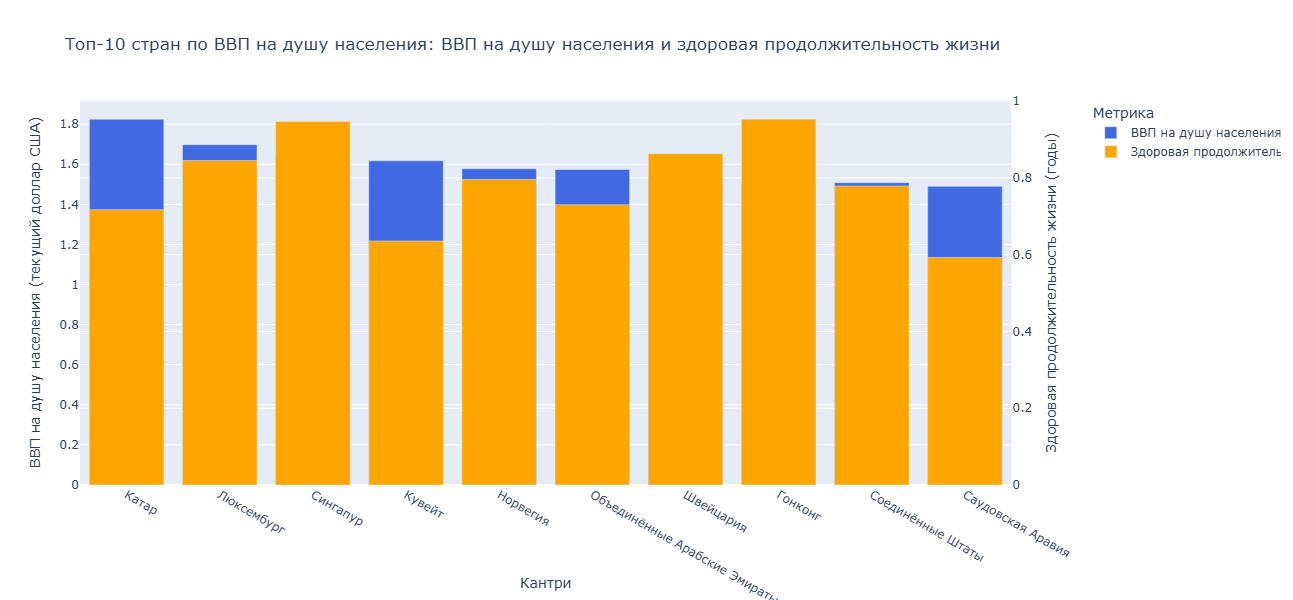

In [42]:
!pip install -q plotly ipywidgets

import plotly.io as pio
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True) 
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

country_col = 'Country'
gdp_col     = 'Economy (GDP per Capita)'
hle_col     = 'Health (Life Expectancy)'

tmp = df[[country_col, gdp_col, hle_col]].copy()

# Convert columns to numeric
tmp[gdp_col] = pd.to_numeric(tmp[gdp_col], errors='coerce')
tmp[hle_col] = pd.to_numeric(tmp[hle_col], errors='coerce')

# Drop rows with missing values in any of the key columns
tmp = tmp.dropna(subset=[country_col, gdp_col, hle_col])

#top 10 countries by GDP per capita
top10 = tmp.sort_values(by=gdp_col, ascending=False).head(10)

# === 6. Create the plot ===
fig1 = make_subplots(specs=[[{"secondary_y": True}]])

# GDP per capita bars on the primary y-axis
fig1.add_trace(
    go.Bar(
        x=top10[country_col], 
        y=top10[gdp_col], 
        name="GDP per capita", 
        marker_color='royalblue'
    ),
    secondary_y=False
)

# Healthy Life Expectancy bars on the secondary y-axis
fig1.add_trace(
    go.Bar(
        x=top10[country_col], 
        y=top10[hle_col], 
        name="Healthy Life Expectancy", 
        marker_color='orange'
    ),
    secondary_y=True
)

fig1.update_layout(
    title_text="Top 10 Countries by GDP per Capita: GDP per Capita and Healthy Life Expectancy",
    barmode='group',
    xaxis_title="Country",
    legend_title="Metric",
    height=600
)

fig1.update_yaxes(title_text="GDP per Capita (current US$)", secondary_y=False)
fig1.update_yaxes(title_text="Healthy Life Expectancy (years)", secondary_y=True)

fig1.show()






**The bar chart** compares the top 10 countries by GDP per Capita alongside Healthy Life Expectancy. Most of these countries demonstrate both strong economic performance and high health outcomes. However, variations suggest that factors beyond wealth, such as healthcare quality and lifestyle, also influence life expectancy.

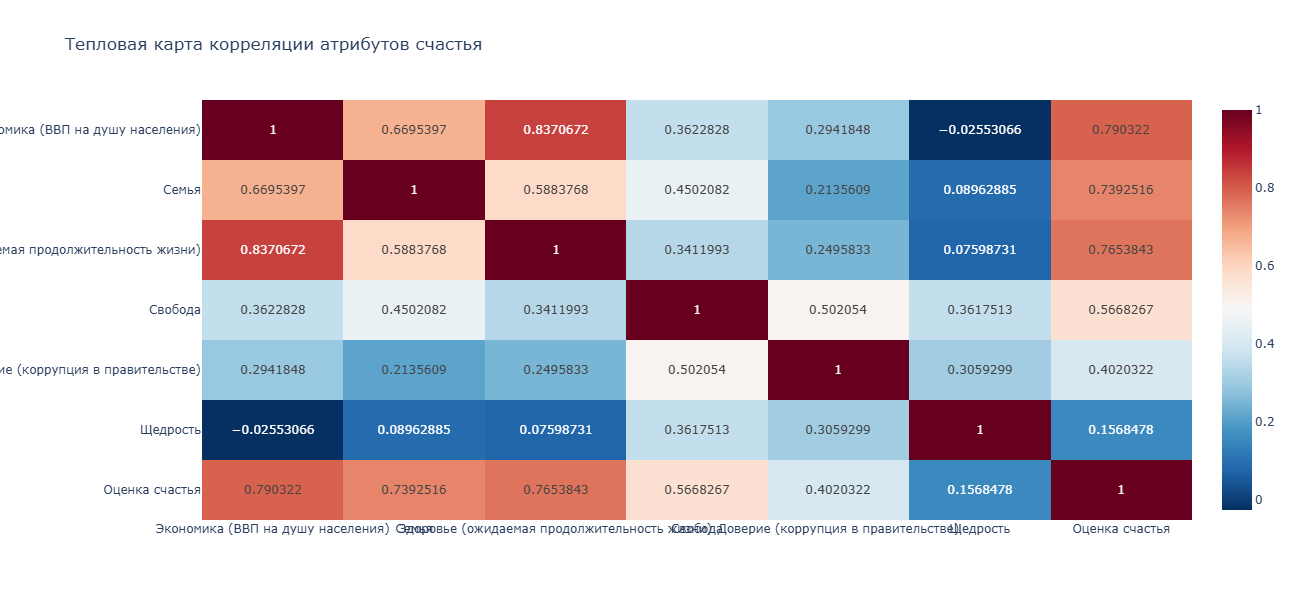

In [43]:
import plotly.express as px

#sub-dataset with the specified columns
sub_cols = [
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity',
    'Happiness Score'
]

sub_df = df[sub_cols].copy()

sub_df = sub_df.apply(pd.to_numeric, errors='coerce').dropna()

#Compute correlation matrix
corr_matrix = sub_df.corr()


#heatmap using Plotly
fig2 = px.imshow(
    corr_matrix,
    text_auto=True,     
    aspect="auto",
    width=800,
    height=600,
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap of Happiness Attributes"
)

fig2.show()

**Correlation Heatmap**

The heatmap presents the correlation between socio-economic and well-being attributes, including GDP per Capita, Family, Health (Life Expectancy), Freedom, Trust in Government, Generosity, and Happiness Score.

We can observe strong positive correlations between GDP per Capita, Family, Health, and Happiness Score, indicating that wealth, social support, and health are key contributors to happiness.

Attributes like Freedom and Trust also positively correlate with Happiness, though to a lesser extent, while Generosity shows a weaker correlation.

This visualization highlights how multiple factors are interconnected, showing that countries performing well in one area tend to perform well in others too.

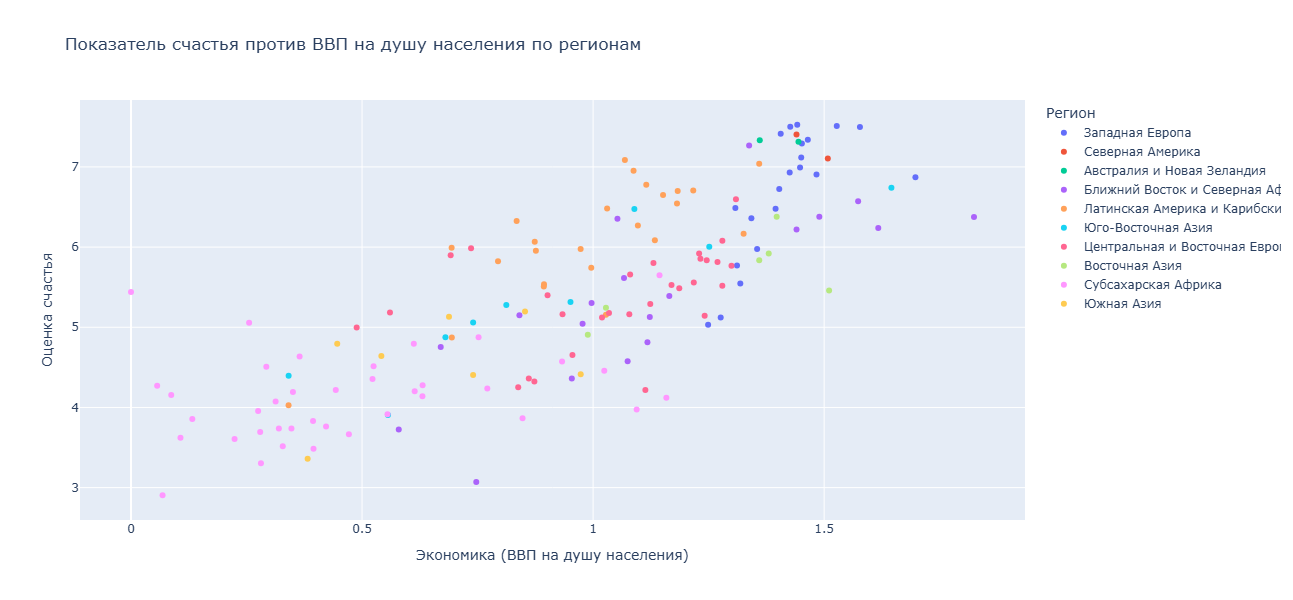

In [44]:
scatter_df = df[['Happiness Score', 'Economy (GDP per Capita)', 'Region']].copy()
scatter_df['Happiness Score'] = pd.to_numeric(scatter_df['Happiness Score'], errors='coerce')
scatter_df['Economy (GDP per Capita)'] = pd.to_numeric(scatter_df['Economy (GDP per Capita)'], errors='coerce')
scatter_df = scatter_df.dropna(subset=['Happiness Score', 'Economy (GDP per Capita)', 'Region'])

fig3 = px.scatter(
    scatter_df,
    x='Economy (GDP per Capita)',
    y='Happiness Score',
    color='Region',              # Color points by Region
    hover_name='Region',         # Show Region on hover
    width=800,
    height=600,
    title='Happiness Score vs GDP per Capita by Region'
)

fig3.show()


**Scatter Plot: GDP per Capita vs Happiness Score by Region**

The scatter plot allows us to explore the relationship between GDP per Capita and Happiness Score across different regions.

There is a clear positive trend, suggesting that higher economic wealth generally supports higher happiness.

The color coding by region reveals regional patterns, where Western Europe and North America cluster in the higher GDP and happiness range, whereas Sub-Saharan Africa and South Asia tend to have lower GDP and happiness scores.

Some outliers indicate that economic wealth alone does not fully determine happiness, highlighting the importance of other social and policy factors.

C:\Users\chebo\AppData\Local\Temp\ipykernel_2932\4044818173.py:6: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



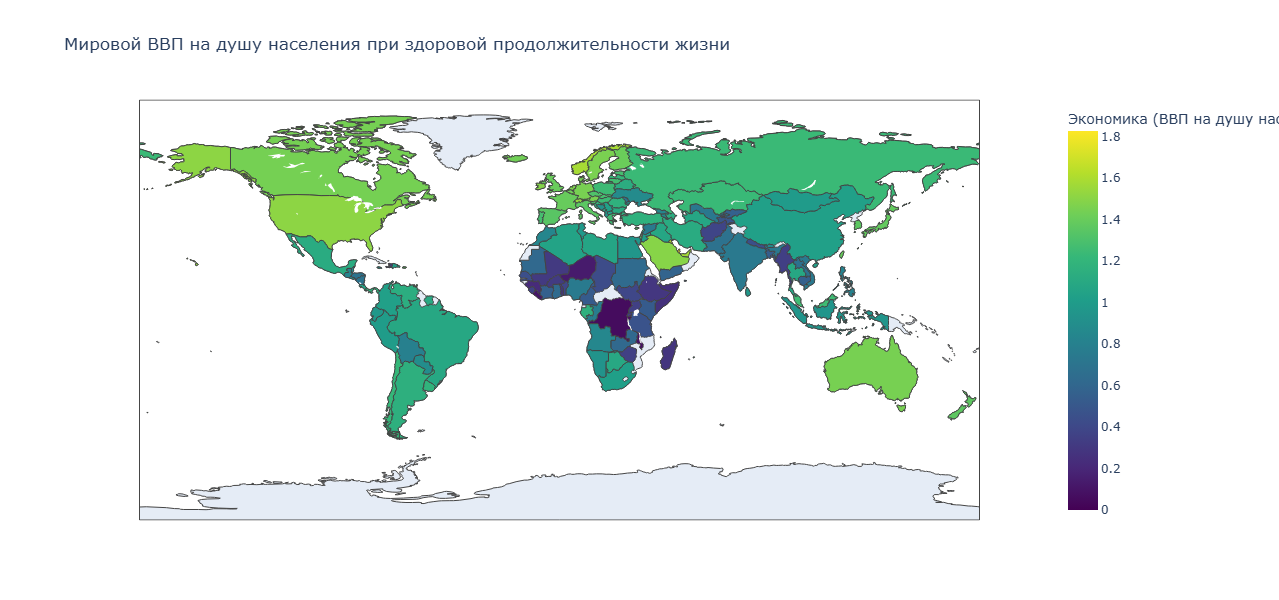

In [45]:
map_df = df[['Country', 'Economy (GDP per Capita)', 'Health (Life Expectancy)']].copy()
map_df['Economy (GDP per Capita)'] = pd.to_numeric(map_df['Economy (GDP per Capita)'], errors='coerce')
map_df['Health (Life Expectancy)'] = pd.to_numeric(map_df['Health (Life Expectancy)'], errors='coerce')
map_df = map_df.dropna(subset=['Country', 'Economy (GDP per Capita)', 'Health (Life Expectancy)'])

fig5 = px.choropleth(
    map_df,
    locations='Country',                   # Column with country nam
    locationmode='country names',          # Interpret as country names
    color='Economy (GDP per Capita)',      # Color by GDP per capita
    hover_name='Country',                  # country name on hover
    hover_data={'Health (Life Expectancy)': True, 
                'Economy (GDP per Capita)': ':.2f'}, 
    color_continuous_scale='Viridis', 
    title='World GDP per Capita with Healthy Life Expectancy',
    width=1000,
    height=600
)

fig5.show()


**World Map: GDP per Capita and Healthy Life Expectancy**

The choropleth map visualizes GDP per Capita across countries, while the tooltip shows Healthy Life Expectancy.
Countries with higher GDP are prominently colored, making global economic patterns immediately visible.
The interactive tooltips provide additional context on health outcomes, allowing us to see how wealth and healthy life expectancy interact in shaping overall happiness.
This visualization emphasizes both geographical and socio-economic dimensions of well-being.

### Findings / Conclusions

**Positive correlation between GDP per Capita and Happiness Score**
Countries with higher GDP per capita generally tend to have higher happiness scores, indicating that economic wealth contributes to overall well-being.

Regional patterns are visible
Different regions cluster in distinct areas of the plot. For example, North America and Western Europe tend to have both higher GDP and higher Happiness Scores, while regions like Sub-Saharan Africa and South Asia tend to cluster in the lower-left quadrant.

Some outliers exist
A few countries have relatively high GDP but lower happiness scores, or lower GDP with higher happiness, suggesting that wealth alone does not fully determine happiness—other factors like governance, health, and social support play roles.

Heterogeneity within regions
Even within the same region, there is noticeable variation in Happiness Scores and GDP per Capita, highlighting that local policies, culture, and social factors can strongly influence well-being.

## Conclusions

##### Together, these visualizations provide a comprehensive understanding of the factors that influence happiness globally:

##### Economic wealth, health, family, and freedom are key drivers.

##### Regional differences highlight inequality and potential areas for policy improvement.

##### The dashboard allows for interactive exploration, making patterns and correlations easy to identify for policymakers, researchers, and the general public.

In [39]:
df.to_csv("happiness.csv", index=False, encoding="utf-8-sig")


In [40]:
corr_matrix.to_csv("corr_matrix.csv")